In [1]:
# import necessary libraries for data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the CSV file into a pandas DataFrame
df = pd.read_csv('loan_approval_data.csv', low_memory=False)

In [3]:
# Display basic information about the dataset
df.shape

(58645, 16)

In [4]:
# Display first 5 rows of the Dataframe
df.head().T

,0,1,2,3,4
id,35437,53756,42205,19180,28072
age,21,21,23,40,40
Sex,M,M,M,M,M
Education_Qualifications,Unknown,Unknown,Unknown,Unknown,Unknown
income,12000,13200,9600,182004,90000
home_ownership,OWN,OWN,RENT,RENT,MORTGAGE
emplyment_length,0,2,5,3,3
loan_intent,EDUCATION,EDUCATION,MEDICAL,EDUCATION,HOMEIMPROVEMENT
loan_amount,15000,25000,30000,35000,35000
loan_interest_rate,6.99,16.77,12.42,8.0,12.42


In [5]:
# Standardize the values
cat_cols = df.select_dtypes(include=['str']).columns.tolist()

for c in cat_cols:
    df[c] = df[c].astype(str).str.strip().str.lower()

In [6]:
df.head().T

,0,1,2,3,4
id,35437,53756,42205,19180,28072
age,21,21,23,40,40
Sex,m,m,m,m,m
Education_Qualifications,unknown,unknown,unknown,unknown,unknown
income,12000,13200,9600,182004,90000
home_ownership,own,own,rent,rent,mortgage
emplyment_length,0,2,5,3,3
loan_intent,education,education,medical,education,homeimprovement
loan_amount,15000,25000,30000,35000,35000
loan_interest_rate,6.99,16.77,12.42,8.0,12.42


In [7]:
# Check value counts
df.value_counts()

id     age  Sex  Education_Qualifications  income  home_ownership  emplyment_length  loan_intent      loan_amount  loan_interest_rate  loan_income_ratio  payment_default_on_file  credit_history_length  loan_approval_status  max_allowed_loan  Credit_Application_Acceptance
35437  21   m    unknown                   12000   own             0                 education        15000        6.99                0.12               n                        4                      approved              -2426900          0.0                              1
53756  21   m    unknown                   13200   own             2                 education        25000        16.77               0.19               y                        3                      approved              -111739           0.0                              1
42205  23   m    unknown                   9600    rent            5                 medical          30000        12.42               0.31               n                   

In [8]:
# Display basic statistical information
df.describe()

,id,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,max_allowed_loan,Credit_Application_Acceptance
count,58645.000000,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58645.000000,5.864500e+04,58644.000000
mean,29322.000000,6.404617e+04,4.703487,9217.556518,10.685988,0.159238,5.813556,2.823538e+05,0.142385
std,16929.497605,3.793111e+04,4.004982,5563.807384,3.161955,0.091692,4.029196,5.148478e+07,0.349447
min,0.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,2.000000,-2.426900e+06,0.000000
25%,14661.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,3.800300e+04,0.000000
50%,29322.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,6.239200e+04,0.000000
75%,43983.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,9.271600e+04,0.000000
max,58644.000000,1.900000e+06,150.000000,35000.000000,150.000000,0.830000,30.000000,1.246799e+10,1.000000


The stats reveal some suspicious values:

- loan_interest_rate has a min of -11.14 — negative interest rates don't make sense
- max_allowed_loan has a min of -2,426,900 — negative loan limits are invalid
- emplyment_length has a max of 150 — no one works 150 years

In [9]:
# Inspect these outliers before filling
print(df[df['loan_interest_rate'] < 0]['loan_interest_rate'].value_counts())
print(df[df['max_allowed_loan'] < 0]['max_allowed_loan'].value_counts())
print(df[df['emplyment_length'] > 60]['emplyment_length'].value_counts())

loan_interest_rate
-11.14    1
Name: count, dtype: int64
max_allowed_loan
-2426900    1
-111739     1
-89000      1
Name: count, dtype: int64
emplyment_length
123    2
150    1
Name: count, dtype: int64


In [10]:
# Fix invalid values
df.loc[df['loan_interest_rate'] < 0, 'loan_interest_rate'] = np.nan
df.loc[df['max_allowed_loan'] < 0, 'max_allowed_loan'] = np.nan
df.loc[df['emplyment_length'] > 60, 'emplyment_length'] = np.nan

In [11]:
# Check data types
df.dtypes

id                                 int64
age                                  str
Sex                                  str
Education_Qualifications             str
income                             int64
home_ownership                       str
emplyment_length                 float64
loan_intent                          str
loan_amount                        int64
loan_interest_rate               float64
loan_income_ratio                float64
payment_default_on_file              str
credit_history_length              int64
loan_approval_status                 str
max_allowed_loan                 float64
Credit_Application_Acceptance    float64
dtype: object

In [12]:
# Convert age to numeric
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [13]:
# Check value counts for loan approval status
df['loan_approval_status'].value_counts()

loan_approval_status
approved    50215
declined     8272
accept         79
reject         78
Name: count, dtype: int64

In [14]:
# Map all variations to the same value
df['loan_approval_status'] = df['loan_approval_status'].replace({
    'approved': 1,
    'accept':   1,
    'declined': 0,
    'rejected': 0,
    'reject':   0,
    'decline':  0
})

In [15]:
# Check for missing values
df.isnull().sum()

id                                   0
age                                  9
Sex                              58424
Education_Qualifications             0
income                               0
home_ownership                       0
emplyment_length                     3
loan_intent                          0
loan_amount                          0
loan_interest_rate                  12
loan_income_ratio                    0
payment_default_on_file              5
credit_history_length                0
loan_approval_status                 1
max_allowed_loan                     3
Credit_Application_Acceptance        1
dtype: int64

In [16]:
# Drop bad columns
df = df.drop(columns=['Sex', 'id'])

In [17]:
df.head().T

,0,1,2,3,4
age,21.0,21.0,23.0,40.0,40.0
Education_Qualifications,unknown,unknown,unknown,unknown,unknown
income,12000,13200,9600,182004,90000
home_ownership,own,own,rent,rent,mortgage
emplyment_length,0.0,2.0,5.0,3.0,3.0
loan_intent,education,education,medical,education,homeimprovement
loan_amount,15000,25000,30000,35000,35000
loan_interest_rate,6.99,16.77,12.42,8.0,12.42
loan_income_ratio,0.12,0.19,0.31,0.19,0.39
payment_default_on_file,n,y,n,n,n


In [18]:
print(df[['Credit_Application_Acceptance', 'loan_approval_status']].value_counts())

Credit_Application_Acceptance  loan_approval_status
0.0                            1                       50294
1.0                            0                        8350
Name: count, dtype: int64


--> This means this column is essentially the same as your target variable, just encoded differently. It has to be dropped

In [19]:
# Dropping unnecessary columns
df = df.drop(columns=['Education_Qualifications', 'Credit_Application_Acceptance'])

In [20]:
# Fill numeric columns
numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns
cat_cols = df.select_dtypes(include='str').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode().iloc[0])

In [21]:
df.head().T

,0,1,2,3,4
age,21.0,21.0,23.0,40.0,40.0
income,12000,13200,9600,182004,90000
home_ownership,own,own,rent,rent,mortgage
emplyment_length,0.0,2.0,5.0,3.0,3.0
loan_intent,education,education,medical,education,homeimprovement
loan_amount,15000,25000,30000,35000,35000
loan_interest_rate,6.99,16.77,12.42,8.0,12.42
loan_income_ratio,0.12,0.19,0.31,0.19,0.39
payment_default_on_file,n,y,n,n,n
credit_history_length,4,3,3,11,14


In [22]:
df.dtypes

age                        float64
income                       int64
home_ownership                 str
emplyment_length           float64
loan_intent                    str
loan_amount                  int64
loan_interest_rate         float64
loan_income_ratio          float64
payment_default_on_file        str
credit_history_length        int64
loan_approval_status        object
max_allowed_loan           float64
dtype: object

In [23]:
# Drop the NaN rows
df = df.dropna(subset=['loan_approval_status'])

# Target variable is still not converted to numeric
df['loan_approval_status'] = df['loan_approval_status'].astype(int)

# Verify
print(df['loan_approval_status'].dtype)

int64


In [24]:
df['loan_approval_status'].value_counts()

loan_approval_status
1    50294
0     8350
Name: count, dtype: int64

## Pattern Discovery

### Does higher income correlate with higher approval rates?

In [25]:
# Split income into groups (bins) and check approval rate per group
df['income_group'] = pd.cut(df['income'], 
                             bins=[0, 30000, 60000, 100000, 200000, df['income'].max()],
                             labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# Calculate approval rate per income group
income_approval = df.groupby('income_group', observed=True)['loan_approval_status'].mean() * 100
print("Approval Rate by Income Group:")
print(income_approval.round(2))

Approval Rate by Income Group:
income_group
Very Low     66.48
Low          83.68
Medium       91.52
High         96.16
Very High    97.13
Name: loan_approval_status, dtype: float64


- Yes, higher income strongly correlates with higher loan approval rates in this dataset.

### Does credit history influence loan approval?

In [26]:
# Group credit history into short, medium, long
df['credit_group'] = pd.cut(df['credit_history_length'],
                              bins=[0, 3, 7, 15, df['credit_history_length'].max()],
                              labels=['Short (0-3yrs)', 'Medium (3-7yrs)', 
                                      'Long (7-15yrs)', 'Very Long (15+yrs)'])

# Approval rate per credit history group
credit_approval = df.groupby('credit_group', observed=True)['loan_approval_status'].mean() * 100
print("\nApproval Rate by Credit History Length:")
print(credit_approval.round(2))


Approval Rate by Credit History Length:
credit_group
Short (0-3yrs)        85.19
Medium (3-7yrs)       86.12
Long (7-15yrs)        86.28
Very Long (15+yrs)    84.35
Name: loan_approval_status, dtype: float64


- Based on the results, credit history length has very little influence on loan approval in your dataset.

### Are certain loan purposes more likely to be approved?

In [27]:
# Approval rate by loan intent/purpose
intent_approval = df.groupby('loan_intent')['loan_approval_status'].mean() * 100
intent_approval = intent_approval.sort_values(ascending=False)

print("\nApproval Rate by Loan Purpose:")
print(intent_approval.round(2))


Approval Rate by Loan Purpose:
loan_intent
venture              90.72
education            89.23
personal             86.72
homeimprovement      82.63
medical              82.17
debtconsolidation    81.07
Name: loan_approval_status, dtype: float64


- Venture and Education loans are most likely to be approved at over 89%, while Debt Consolidation sits lowest at 81%. However, the spread between highest and lowest is only about 10 percentage points (90.72% vs 81.07%), which means loan purpose alone is not a strong deciding factor, all categories still have high approval rates overall.

## Visualizations

### Income vs Loan Approval

In [28]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make all charts look clean
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

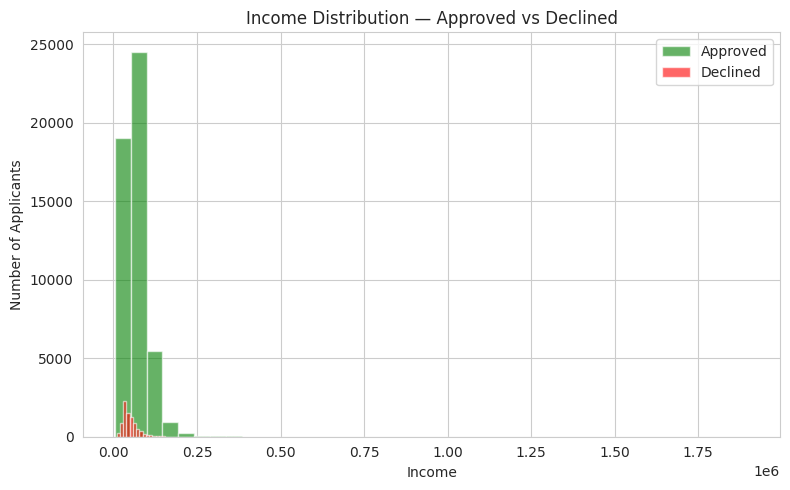

In [30]:
plt.figure(figsize=(8, 5))

# Plot income distribution for approved vs declined
approved = df[df['loan_approval_status'] == 1]['income']
declined = df[df['loan_approval_status'] == 0]['income']

plt.hist(approved, bins=40, alpha=0.6, color='green', label='Approved')
plt.hist(declined, bins=40, alpha=0.6, color='red',   label='Declined')

plt.title('Income Distribution — Approved vs Declined')
plt.xlabel('Income')
plt.ylabel('Number of Applicants')
plt.legend()
plt.tight_layout()
plt.show()

### Approval Rate by Income Group

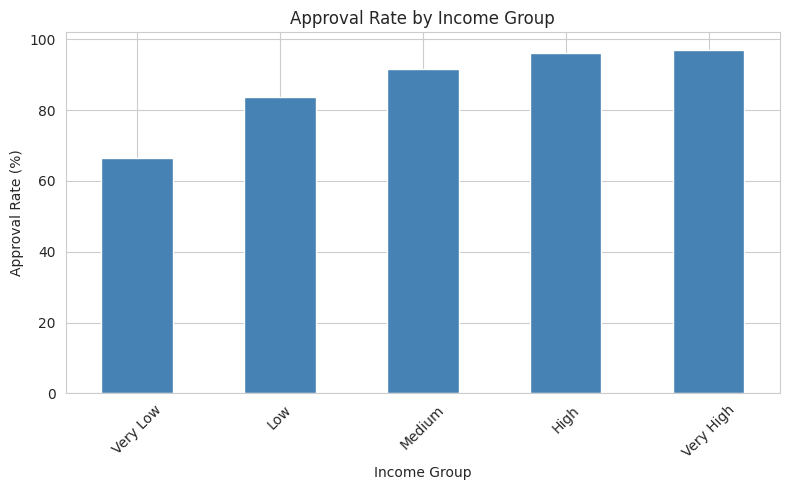

In [31]:
plt.figure(figsize=(8, 5))

income_approval.plot(kind='bar', color='steelblue', edgecolor='white')

plt.title('Approval Rate by Income Group')
plt.xlabel('Income Group')
plt.ylabel('Approval Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Credit History vs Approval Rate

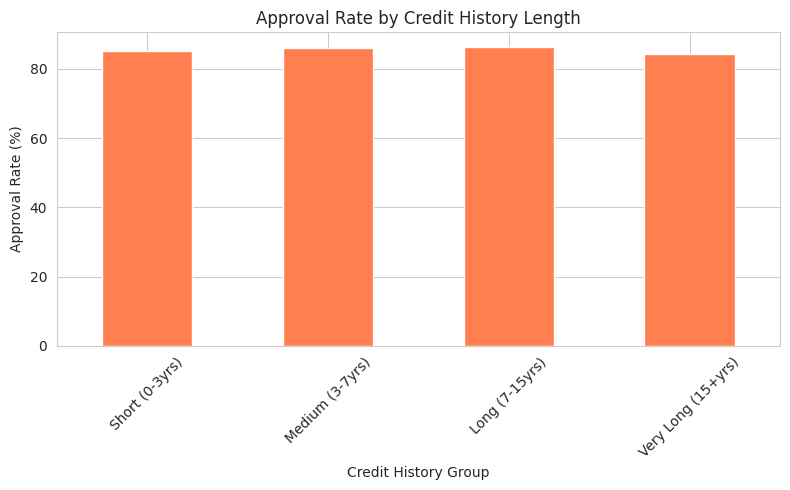

In [32]:
plt.figure(figsize=(8, 5))

credit_approval.plot(kind='bar', color='coral', edgecolor='white')

plt.title('Approval Rate by Credit History Length')
plt.xlabel('Credit History Group')
plt.ylabel('Approval Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Loan Purpose vs Approval Rate

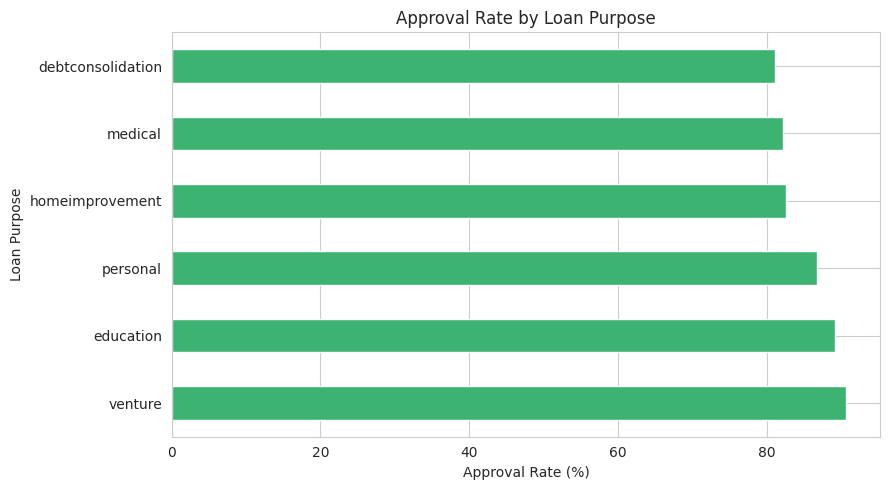

In [33]:
plt.figure(figsize=(9, 5))

intent_approval.plot(kind='barh', color='mediumseagreen', edgecolor='white')

plt.title('Approval Rate by Loan Purpose')
plt.xlabel('Approval Rate (%)')
plt.ylabel('Loan Purpose')
plt.tight_layout()
plt.show()

### Correlation Heatmap (all numeric features)

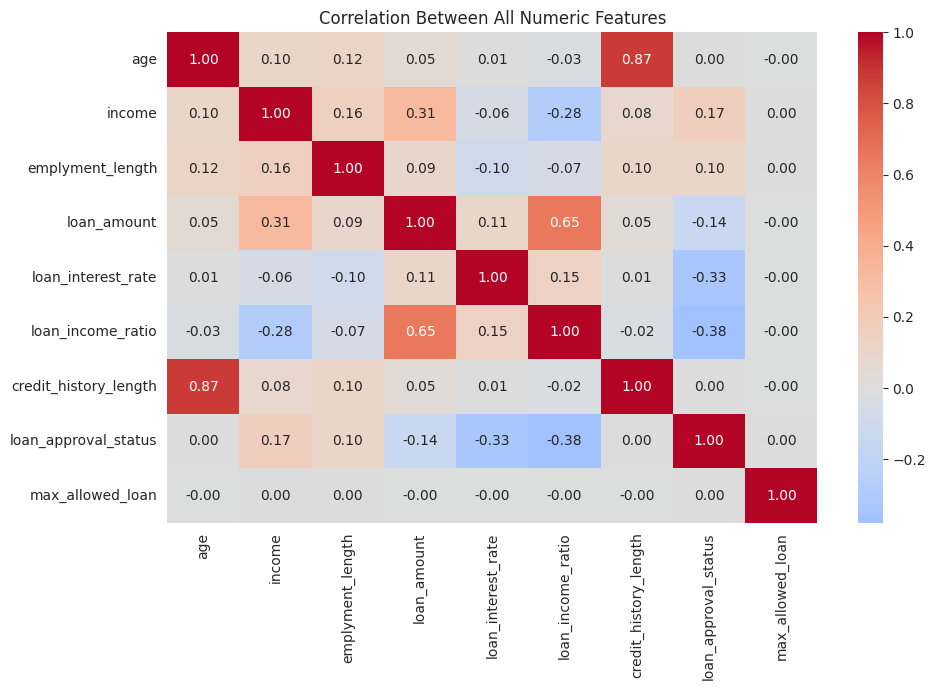

In [34]:
plt.figure(figsize=(10, 7))

# Only numeric columns
numeric_df = df.select_dtypes(include='number')

sns.heatmap(numeric_df.corr(), 
            annot=True,       # show numbers in each cell
            fmt='.2f',        # 2 decimal places
            cmap='coolwarm',  # red = positive, blue = negative
            center=0)

plt.title('Correlation Between All Numeric Features')
plt.tight_layout()
plt.show()

- Bottom line: loan_income_ratio and loan_interest_rate are your two strongest numeric predictors of loan approval. age should be dropped since it's almost perfectly duplicated by credit_history_length. And max_allowed_loan adds absolutely nothing.

### Summary for the Loan Model

In [35]:
# Based on the heatmap, your most useful features are:
useful_features = [
    'income',            # +0.17 with approval
    'loan_interest_rate', # -0.33 with approval
    'loan_income_ratio',  # -0.38 with approval (strongest predictor)
    'loan_amount',        # -0.14 with approval
    'emplyment_length',   # +0.10 with approval
    'credit_history_length'  # keep this, drop age since they're nearly identical
]

# Drop redundant and useless columns
df = df.drop(columns=['age', 'max_allowed_loan'])

In [36]:
# Check the thresholds first
# Check median values for approved vs declined applicants
print("=== Approved Applicants ===")
print(df[df['loan_approval_status'] == 1][['income', 'loan_income_ratio', 
      'loan_interest_rate', 'credit_history_length', 
      'emplyment_length']].median())

print("\n=== Declined Applicants ===")
print(df[df['loan_approval_status'] == 0][['income', 'loan_income_ratio', 
      'loan_interest_rate', 'credit_history_length', 
      'emplyment_length']].median())

=== Approved Applicants ===
income                   60000.00
loan_income_ratio            0.13
loan_interest_rate          10.39
credit_history_length        4.00
emplyment_length             4.00
dtype: float64

=== Declined Applicants ===
income                   44000.00
loan_income_ratio            0.25
loan_interest_rate          13.79
credit_history_length        4.00
emplyment_length             3.00
dtype: float64


### Build the Rule System

In [37]:
def credit_decision(applicant):
    """
    Rule-based loan decision system.
    Built on the 5 most important features from the correlation heatmap:
      - loan_income_ratio  (-0.38) strongest predictor
      - loan_interest_rate (-0.33)
      - income             (+0.17)
      - emplyment_length   (+0.10)
      - credit_history_length
      - payment_default_on_file (behavioral risk flag)
    """

    score   = 0      # accumulates points
    reasons = []     # reasons for decline
    flags   = []     # positive reasons for approval

    # ── RULE 1: Loan-to-Income Ratio (strongest predictor at -0.38) ──
    ratio = applicant['loan_income_ratio']
    if ratio <= 0.20:
        score += 3
        flags.append(f"Excellent loan-income ratio ({ratio:.2f})")
    elif ratio <= 0.35:
        score += 2
        flags.append(f"Acceptable loan-income ratio ({ratio:.2f})")
    elif ratio <= 0.50:
        score += 1
        reasons.append(f"High loan-income ratio ({ratio:.2f}) — borderline")
    else:
        score += 0
        reasons.append(f"Loan-income ratio too high ({ratio:.2f}) — exceeds 0.50 limit")

    # ── RULE 2: Interest Rate (-0.33 correlation) ──
    rate = applicant['loan_interest_rate']
    if rate <= 8:
        score += 3
        flags.append(f"Low interest rate ({rate:.2f}%)")
    elif rate <= 12:
        score += 2
        flags.append(f"Moderate interest rate ({rate:.2f}%)")
    elif rate <= 15:
        score += 1
        reasons.append(f"Elevated interest rate ({rate:.2f}%)")
    else:
        score += 0
        reasons.append(f"Interest rate too high ({rate:.2f}%) — exceeds 15% limit")

    # ── RULE 3: Income (+0.17 correlation) ──
    income = applicant['income']
    if income >= 80000:
        score += 3
        flags.append(f"High income (${income:,.0f})")
    elif income >= 50000:
        score += 2
        flags.append(f"Moderate income (${income:,.0f})")
    elif income >= 30000:
        score += 1
        reasons.append(f"Low income (${income:,.0f}) — minimum met")
    else:
        score += 0
        reasons.append(f"Income too low (${income:,.0f}) — below $30,000 minimum")

    # ── RULE 4: Credit History Length ──
    history = applicant['credit_history_length']
    if history >= 10:
        score += 3
        flags.append(f"Strong credit history ({history} years)")
    elif history >= 5:
        score += 2
        flags.append(f"Decent credit history ({history} years)")
    elif history >= 3:
        score += 1
        reasons.append(f"Short credit history ({history} years)")
    else:
        score += 0
        reasons.append(f"Very short credit history ({history} years) — below 3 year minimum")

    # ── RULE 5: Employment Length (+0.10 correlation) ──
    emp = applicant['emplyment_length']
    if emp >= 5:
        score += 2
        flags.append(f"Stable employment ({emp} years)")
    elif emp >= 1:
        score += 1
        flags.append(f"Some employment history ({emp} years)")
    else:
        score += 0
        reasons.append("No employment history")

    # ── RULE 6: Prior Default (hard disqualifier) ──
    default = applicant['payment_default_on_file']
    has_default = str(default).strip().lower() == 'y'
    if has_default:
        score -= 3   # heavy penalty
        reasons.append("Prior payment default on file — high risk flag")
    else:
        flags.append("No prior defaults")

    # ── FINAL DECISION ──
    # Max possible score = 3+3+3+3+2 = 14
    # Penalty for default = -3
    if has_default and score < 8:
        decision = 'DECLINED'
        grade    = 'High Risk'
    elif score >= 11:
        decision = 'APPROVED'
        grade    = 'Low Risk'
    elif score >= 8:
        decision = 'APPROVED'
        grade    = 'Medium Risk — Monitor'
    elif score >= 5:
        decision = 'DECLINED'
        grade    = 'Borderline — Manual Review'
    else:
        decision = 'DECLINED'
        grade    = 'High Risk'

    return {
        'decision' : decision,
        'grade'    : grade,
        'score'    : f"{score}/14",
        'approvals': flags,
        'reasons'  : reasons
    }

### Test on a Single Applicant

In [38]:
# Demo with an applicant
applicant = df.iloc[24]
result    = credit_decision(applicant)

print("=" * 40)
print(f"  DECISION : {result['decision']}")
print(f"  GRADE    : {result['grade']}")
print(f"  SCORE    : {result['score']}")
print("=" * 40)

if result['approvals']:
    print("\n✔ Positive Factors:")
    for f in result['approvals']:
        print(f"   + {f}")

if result['reasons']:
    print("\n✘ Risk Factors:")
    for r in result['reasons']:
        print(f"   - {r}")

  DECISION : APPROVED
  GRADE    : Medium Risk — Monitor
  SCORE    : 9/14

✔ Positive Factors:
   + Acceptable loan-income ratio (0.28)
   + Moderate income ($72,000)
   + Strong credit history (16 years)
   + Some employment history (3.0 years)
   + No prior defaults

✘ Risk Factors:
   - Elevated interest rate (13.47%)


### Run on Entire Dataset & Evaluate

In [39]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [40]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Apply rule to every row
df['rule_decision'] = df.apply(
    lambda row: 1 if credit_decision(row)['decision'] == 'APPROVED' else 0,
    axis=1
)

# Accuracy vs actual outcomes
accuracy = accuracy_score(df['loan_approval_status'], df['rule_decision'])
print(f"Rule-Based System Accuracy: {accuracy:.2%}\n")
print(classification_report(df['loan_approval_status'], df['rule_decision'],
                             target_names=['Declined', 'Approved']))

Rule-Based System Accuracy: 75.95%

              precision    recall  f1-score   support

    Declined       0.33      0.67      0.44      8350
    Approved       0.93      0.77      0.85     50294

    accuracy                           0.76     58644
   macro avg       0.63      0.72      0.64     58644
weighted avg       0.85      0.76      0.79     58644



- The system is poor at correctly rejecting risky applicants, it flags too many good applicants as declined (false alarms).

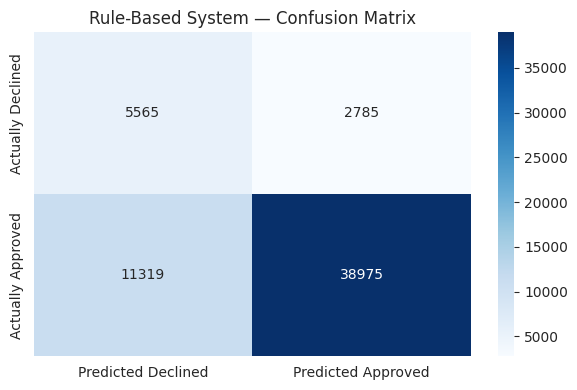


Actual Approval Rate : 85.76%
Rule System Rate     : 71.21%


In [41]:
# Confusion matrix — shows where the rules got it right and wrong
plt.figure(figsize=(6, 4))
cm = confusion_matrix(df['loan_approval_status'], df['rule_decision'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Declined', 'Predicted Approved'],
            yticklabels=['Actually Declined', 'Actually Approved'])
plt.title('Rule-Based System — Confusion Matrix')
plt.tight_layout()
plt.show()

# Approval rate comparison
actual_rate = df['loan_approval_status'].mean() * 100
rule_rate   = df['rule_decision'].mean() * 100

print(f"\nActual Approval Rate : {actual_rate:.2f}%")
print(f"Rule System Rate     : {rule_rate:.2f}%")